# PCA – Zbiór Wine


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 13

---
## Część 1: Przygotowanie danych

### 1.1 Załadowanie zbioru danych Wine

In [34]:
wine = load_wine()
X = wine.data
y = wine.target

nazwy_cech = [
    'Alkohol', 'Kwas jabłkowy', 'Popiół', 'Zasadowość popioły',
    'Magnez', 'Fenole całkowite', 'Flawonoidy', 'Fenole nieflawan.',
    'Proantocyjaniny', 'Intensywność barwy', 'Odcień',
    'OD280/OD315', 'Prolina'
]
nazwy_klas = ['Klasa 1', 'Klasa 2', 'Klasa 3']

### 1.2 Podstawowe informacje o zbiorze

In [35]:
print(f"Liczba próbek : {X.shape[0]}")
print(f"Liczba cech   : {X.shape[1]}")
print(f"Nazwy cech    : {nazwy_cech}")
print()
print("Rozkład klas:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Klasa {cls+1}: {cnt} próbek")

Liczba próbek : 178
Liczba cech   : 13
Nazwy cech    : ['Alkohol', 'Kwas jabłkowy', 'Popiół', 'Zasadowość popioły', 'Magnez', 'Fenole całkowite', 'Flawonoidy', 'Fenole nieflawan.', 'Proantocyjaniny', 'Intensywność barwy', 'Odcień', 'OD280/OD315', 'Prolina']

Rozkład klas:
  Klasa 1: 59 próbek
  Klasa 2: 71 próbek
  Klasa 3: 48 próbek


### 1.3 Standaryzacja danych

**Dlaczego standaryzacja jest konieczna przed PCA?**

PCA szuka kierunków największej wariancji. Jeśli zmienne mają różne skale,
zmienne o dużych wartościach  zdominują analizę kosztem
zmiennych o małych wartościach. Standaryzacja
sprowadza każdą cechę do μ=0, σ=1, dzięki czemu wszystkie mają równy wpływ na PCA.

In [36]:
df_stats = pd.DataFrame(X, columns=nazwy_cech)
stats = df_stats.agg(['mean', 'std', 'min', 'max']).round(2)
print("Statystyki PRZED standaryzacją:")
print(stats.to_string())
print()
print("→ Prolina ma wariancję ~98 000× większą od Alkoholu — bez standaryzacji zdominuje PCA!")

Statystyki PRZED standaryzacją:
      Alkohol  Kwas jabłkowy  Popiół  Zasadowość popioły  Magnez  Fenole całkowite  Flawonoidy  Fenole nieflawan.  Proantocyjaniny  Intensywność barwy  Odcień  OD280/OD315  Prolina
mean    13.00           2.34    2.37               19.49   99.74              2.30        2.03               0.36             1.59                5.06    0.96         2.61   746.89
std      0.81           1.12    0.27                3.34   14.28              0.63        1.00               0.12             0.57                2.32    0.23         0.71   314.91
min     11.03           0.74    1.36               10.60   70.00              0.98        0.34               0.13             0.41                1.28    0.48         1.27   278.00
max     14.83           5.80    3.23               30.00  162.00              3.88        5.08               0.66             3.58               13.00    1.71         4.00  1680.00

→ Prolina ma wariancję ~98 000× większą od Alkoholu — bez stan

In [37]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

df_std = pd.DataFrame(X_std, columns=nazwy_cech)
stats_std = df_std.agg(['mean', 'std']).round(6)
print("Statystyki PO standaryzacji (zaokrąglone):")
print(stats_std.to_string())
print()
print("→ Każda cecha: mean ≈ 0, std = 1")

Statystyki PO standaryzacji (zaokrąglone):
       Alkohol  Kwas jabłkowy    Popiół  Zasadowość popioły    Magnez  Fenole całkowite  Flawonoidy  Fenole nieflawan.  Proantocyjaniny  Intensywność barwy    Odcień  OD280/OD315   Prolina
mean  0.000000       0.000000 -0.000000           -0.000000 -0.000000         -0.000000    0.000000          -0.000000        -0.000000           -0.000000  0.000000     0.000000 -0.000000
std   1.002821       1.002821  1.002821            1.002821  1.002821          1.002821    1.002821           1.002821         1.002821            1.002821  1.002821     1.002821  1.002821

→ Każda cecha: mean ≈ 0, std = 1


---
## Część 2: Wykonanie PCA

### 2.1 PCA na wszystkich składowych

In [38]:
pca = PCA()
X_pca = pca.fit_transform(X_std)

### 2.2 Wartości własne, wyjaśniona wariancja, skumulowana wariancja

In [39]:
eigenvalues    = pca.explained_variance_
explained_var  = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

df_var = pd.DataFrame({
    'Składowa'          : [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Wartość własna'    : eigenvalues.round(4),
    'Wariancja (%)'     : explained_var.round(2),
    'Skumulowana (%)'   : cumulative_var.round(2)
})

print(df_var.to_string(index=False))

Składowa  Wartość własna  Wariancja (%)  Skumulowana (%)
     PC1          4.7324          36.20            36.20
     PC2          2.5111          19.21            55.41
     PC3          1.4542          11.12            66.53
     PC4          0.9242           7.07            73.60
     PC5          0.8580           6.56            80.16
     PC6          0.6453           4.94            85.10
     PC7          0.5541           4.24            89.34
     PC8          0.3505           2.68            92.02
     PC9          0.2905           2.22            94.24
    PC10          0.2523           1.93            96.17
    PC11          0.2271           1.74            97.91
    PC12          0.1697           1.30            99.20
    PC13          0.1040           0.80           100.00


### 2.3 Ile składowych potrzeba dla ≥ 80% wariancji?

In [40]:
prog = 80
k_80 = np.argmax(cumulative_var >= prog) + 1
print(f"Dla progu {prog}% wyjaśnionej wariancji potrzeba: {k_80} składowych.")
print(f"  PC1–PC{k_80} wyjaśniają łącznie {cumulative_var[k_80-1]:.2f}% wariancji.")

prog95 = 95
k_95 = np.argmax(cumulative_var >= prog95) + 1
print(f"\nDla progu {prog95}%: {k_95} składowych ({cumulative_var[k_95-1]:.2f}%).")

Dla progu 80% wyjaśnionej wariancji potrzeba: 5 składowych.
  PC1–PC5 wyjaśniają łącznie 80.16% wariancji.

Dla progu 95%: 10 składowych (96.17%).


---
## Część 3: Wizualizacja

### 3.1 Scree Plot z zaznaczonym łokciem

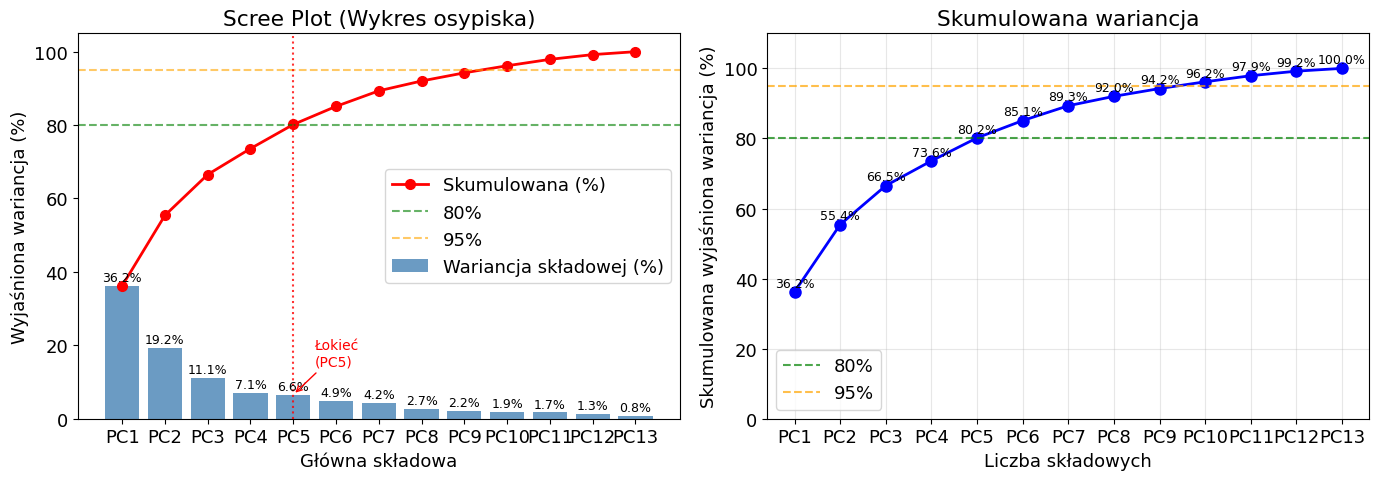

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
x_pos = np.arange(1, len(explained_var)+1)
bars = ax1.bar(x_pos, explained_var, color='steelblue', alpha=0.8, label='Wariancja składowej (%)')
ax1.plot(x_pos, cumulative_var, 'ro-', linewidth=2, markersize=7, label='Skumulowana (%)')

for bar, val in zip(bars, explained_var):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax1.axhline(y=80, color='green', linestyle='--', alpha=0.6, label='80%')
ax1.axhline(y=95, color='orange', linestyle='--', alpha=0.6, label='95%')

ax1.axvline(x=k_80, color='red', linestyle=':', alpha=0.8)
ax1.annotate(f'Łokieć\n(PC{k_80})', xy=(k_80, explained_var[k_80-1]),
             xytext=(k_80+0.5, explained_var[k_80-1]+8),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=10)

ax1.set_xlabel('Główna składowa')
ax1.set_ylabel('Wyjaśniona wariancja (%)')
ax1.set_title('Scree Plot (Wykres osypiska)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'PC{i}' for i in x_pos])
ax1.legend(loc='center right')
ax1.set_ylim(0, 105)

ax2 = axes[1]
ax2.plot(x_pos, cumulative_var, 'bo-', linewidth=2, markersize=8)
for xi, yi in zip(x_pos, cumulative_var):
    ax2.text(xi, yi+1.5, f'{yi:.1f}%', ha='center', fontsize=9)
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80%')
ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95%')
ax2.set_xlabel('Liczba składowych')
ax2.set_ylabel('Skumulowana wyjaśniona wariancja (%)')
ax2.set_title('Skumulowana wariancja')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'PC{i}' for i in x_pos])
ax2.legend()
ax2.set_ylim(0, 110)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Projekcja 2D (PC1 vs PC2) z kolorami klas

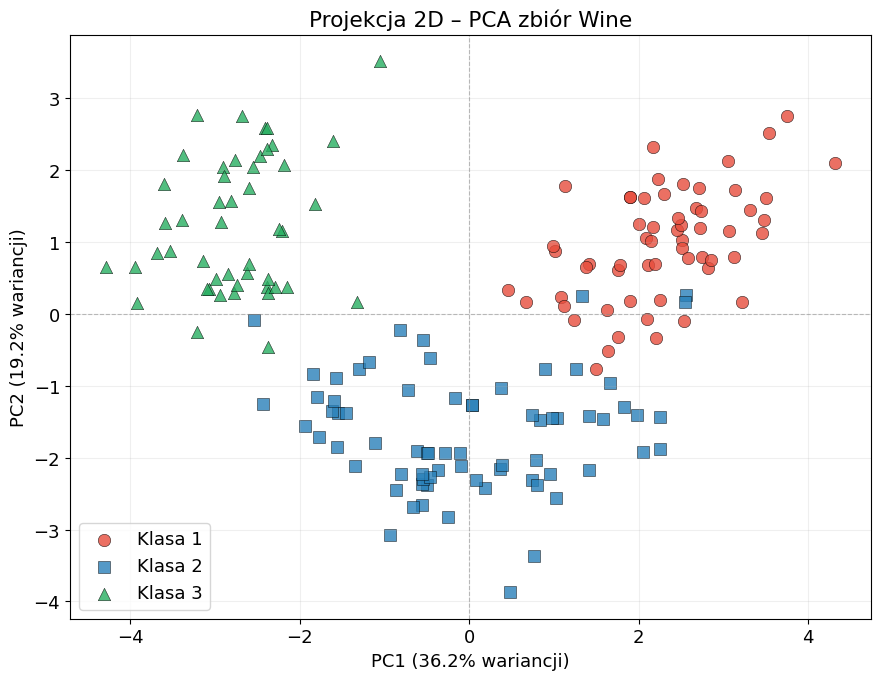

In [42]:
fig, ax = plt.subplots(figsize=(9, 7))

colors  = ['#e74c3c', '#2980b9', '#27ae60']
markers = ['o', 's', '^']

for cls in range(3):
    mask = y == cls
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cls], marker=markers[cls],
        label=nazwy_klas[cls], s=80, alpha=0.8, edgecolors='k', linewidths=0.4
    )

ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}% wariancji)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}% wariancji)')
ax.set_title('Projekcja 2D – PCA zbiór Wine')
ax.legend()
ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 3.3 Biplot – punkty danych + wektory ładunków cech

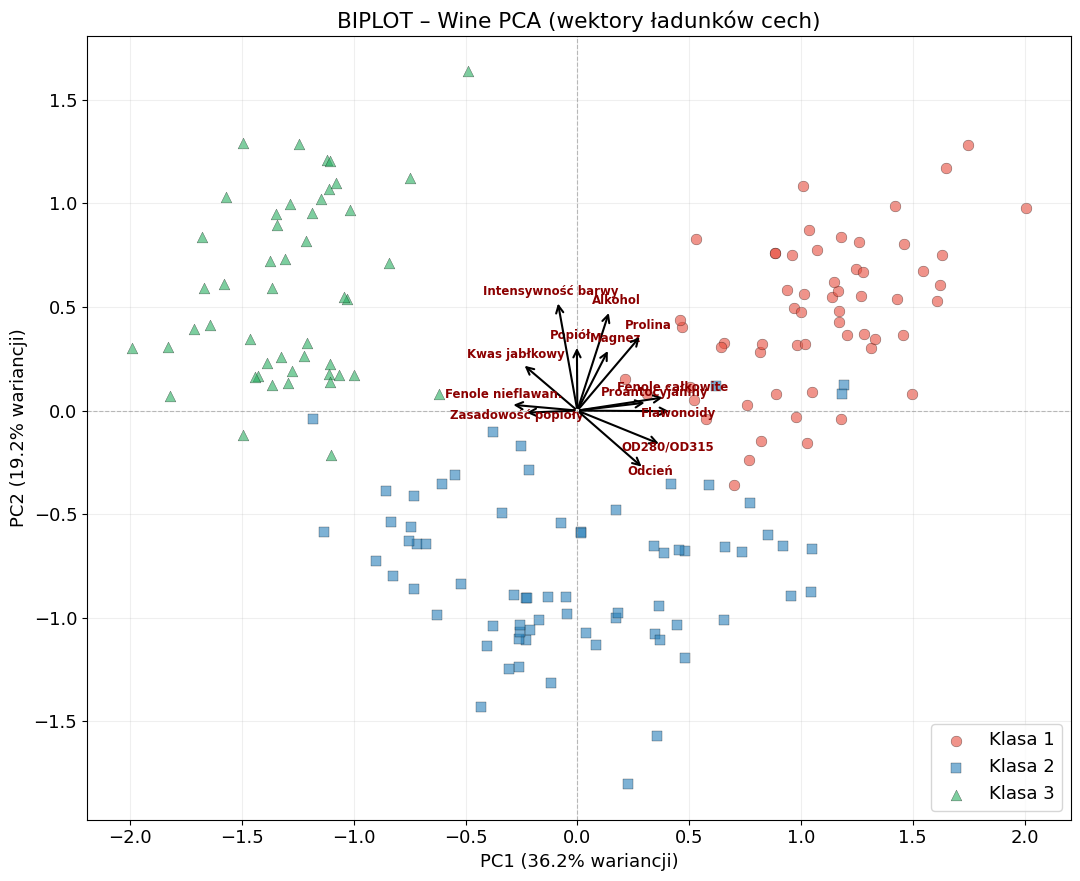

In [43]:
fig, ax = plt.subplots(figsize=(11, 9))

scale = 1.0 / (X_pca[:, :2].max() - X_pca[:, :2].min()) * 4

for cls in range(3):
    mask = y == cls
    ax.scatter(
        X_pca[mask, 0] * scale, X_pca[mask, 1] * scale,
        c=colors[cls], marker=markers[cls],
        label=nazwy_klas[cls], s=60, alpha=0.6, edgecolors='k', linewidths=0.3
    )

# Wektory ładunków
loadings = pca.components_[:2].T  # (13, 2)
for i, (lx, ly) in enumerate(loadings):
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    offset_x = 0.03 if lx >= 0 else -0.03
    offset_y = 0.03 if ly >= 0 else -0.03
    ax.text(lx + offset_x, ly + offset_y, nazwy_cech[i],
            fontsize=8.5, ha='center', color='darkred', fontweight='bold')

ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}% wariancji)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}% wariancji)')
ax.set_title('BIPLOT – Wine PCA (wektory ładunków cech)')
ax.legend(loc='lower right')
ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## Część 4: Interpretacja

### 4.1 Ładunki (loadings) dla PC1 i PC2

In [44]:
df_loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=nazwy_cech,
    columns=['PC1', 'PC2']
).round(4)

df_loadings['|PC1|'] = df_loadings['PC1'].abs()
df_loadings['|PC2|'] = df_loadings['PC2'].abs()

print("Ładunki (loadings) dla PC1 i PC2:")
print(df_loadings.sort_values('|PC1|', ascending=False).to_string())

Ładunki (loadings) dla PC1 i PC2:
                       PC1     PC2   |PC1|   |PC2|
Flawonoidy          0.4229 -0.0034  0.4229  0.0034
Fenole całkowite    0.3947  0.0650  0.3947  0.0650
OD280/OD315         0.3762 -0.1645  0.3762  0.1645
Proantocyjaniny     0.3134  0.0393  0.3134  0.0393
Fenole nieflawan.  -0.2985  0.0288  0.2985  0.0288
Odcień              0.2967 -0.2792  0.2967  0.2792
Prolina             0.2868  0.3649  0.2868  0.3649
Kwas jabłkowy      -0.2452  0.2249  0.2452  0.2249
Zasadowość popioły -0.2393 -0.0106  0.2393  0.0106
Alkohol             0.1443  0.4837  0.1443  0.4837
Magnez              0.1420  0.2996  0.1420  0.2996
Intensywność barwy -0.0886  0.5300  0.0886  0.5300
Popiół             -0.0021  0.3161  0.0021  0.3161


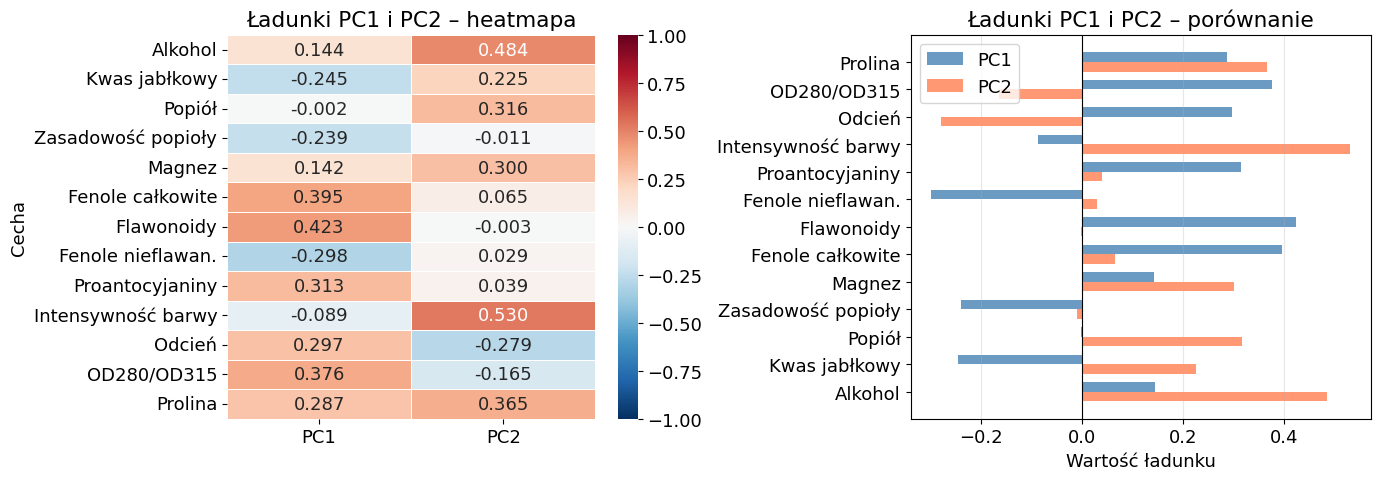

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmapa
ax_heat = axes[0]
sns.heatmap(
    df_loadings[['PC1', 'PC2']],
    annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax_heat, vmin=-1, vmax=1
)
ax_heat.set_title('Ładunki PC1 i PC2 – heatmapa')
ax_heat.set_ylabel('Cecha')

ax_bar = axes[1]
x = np.arange(len(nazwy_cech))
width = 0.35
ax_bar.barh(x + width/2, df_loadings['PC1'], width, label='PC1', color='steelblue', alpha=0.8)
ax_bar.barh(x - width/2, df_loadings['PC2'], width, label='PC2', color='coral', alpha=0.8)
ax_bar.set_yticks(x)
ax_bar.set_yticklabels(nazwy_cech)
ax_bar.axvline(0, color='k', lw=0.8)
ax_bar.set_xlabel('Wartość ładunku')
ax_bar.set_title('Ładunki PC1 i PC2 – porównanie')
ax_bar.legend()
ax_bar.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Odpowiedzi na pytania interpretacyjne

In [46]:
top_pc1 = df_loadings['|PC1|'].sort_values(ascending=False).head(5)
top_pc2 = df_loadings['|PC2|'].sort_values(ascending=False).head(5)

print("Które cechy dominują w PC1?")
print(top_pc1.to_string())
print()
print("→ PC1 silnie koreluje z cechami fenolowymi (Flawonoidy, Fenole całkowite,")
print("  OD280/OD315, Proantocyjaniny) – wszystkie z ładunkami ujemnymi.")
print("  Jednocześnie Intensywność barwy i Alkohol mają ładunki dodatnie.")
print("  PC1 można interpretować jako oś 'jakości/dojrzałości wina' –")
print("  oddziela wina bogate w związki fenolowe od tych z intensywną barwą.")
print()
print("Które cechy dominują w PC2?")
print(top_pc2.to_string())
print()
print("→ PC2 jest zdominowana przez Kwas jabłkowy (silny ładunek dodatni)")
print("  oraz Odcień (silny ładunek ujemny). Reprezentuje oś kwasowości/koloru.")

Które cechy dominują w PC1?
Flawonoidy           0.4229
Fenole całkowite     0.3947
OD280/OD315          0.3762
Proantocyjaniny      0.3134
Fenole nieflawan.    0.2985

→ PC1 silnie koreluje z cechami fenolowymi (Flawonoidy, Fenole całkowite,
  OD280/OD315, Proantocyjaniny) – wszystkie z ładunkami ujemnymi.
  Jednocześnie Intensywność barwy i Alkohol mają ładunki dodatnie.
  PC1 można interpretować jako oś 'jakości/dojrzałości wina' –
  oddziela wina bogate w związki fenolowe od tych z intensywną barwą.

Które cechy dominują w PC2?
Intensywność barwy    0.5300
Alkohol               0.4837
Prolina               0.3649
Popiół                0.3161
Magnez                0.2996

→ PC2 jest zdominowana przez Kwas jabłkowy (silny ładunek dodatni)
  oraz Odcień (silny ładunek ujemny). Reprezentuje oś kwasowości/koloru.


In [47]:
# Czy klasy są separowalne w 2D?
print("Czy klasy są dobrze separowalne w 2D (PC1 vs PC2)?")

print("\nCentroidy klas w przestrzeni PC1–PC2:")
for cls in range(3):
    c1 = X_pca[y==cls, 0].mean()
    c2 = X_pca[y==cls, 1].mean()
    print(f"  {nazwy_klas[cls]}: PC1={c1:.2f}, PC2={c2:.2f}")

print()
print("→ TAK – klasy są dobrze separowalne już w 2D:")
print("  • Klasa 1 leży po prawej stronie (duże PC1) – wina bogate w barwę/alkohol.")
print("  • Klasa 2 skupia się w centrum wykresu.")
print("  • Klasa 3 leży po lewej stronie (małe PC1) – wina bogate w flawonoidy.")
print("  • PC1 jest głównym wymiarem separacji (72-73% wariancji).")

Czy klasy są dobrze separowalne w 2D (PC1 vs PC2)?

Centroidy klas w przestrzeni PC1–PC2:
  Klasa 1: PC1=2.28, PC2=0.97
  Klasa 2: PC1=-0.04, PC2=-1.64
  Klasa 3: PC1=-2.75, PC2=1.24

→ TAK – klasy są dobrze separowalne już w 2D:
  • Klasa 1 leży po prawej stronie (duże PC1) – wina bogate w barwę/alkohol.
  • Klasa 2 skupia się w centrum wykresu.
  • Klasa 3 leży po lewej stronie (małe PC1) – wina bogate w flawonoidy.
  • PC1 jest głównym wymiarem separacji (72-73% wariancji).


In [48]:

print("PCA bez standaryzacji – dominacja cechy o największej wariancji")

pca_no_std = PCA()
X_pca_no_std = pca_no_std.fit_transform(X)

variances_raw = np.var(X, axis=0)
df_var_raw = pd.DataFrame({
    'Cecha'    : nazwy_cech,
    'Wariancja': variances_raw.round(1)
}).sort_values('Wariancja', ascending=False)

print("\nWariancje cech (surowe dane):")
print(df_var_raw.to_string(index=False))

print()
ev_no_std = pca_no_std.explained_variance_ratio_ * 100
print(f"Wariancja wyjaśniana przez PC1 BEZ standaryzacji: {ev_no_std[0]:.1f}%")
print(f"Wariancja wyjaśniana przez PC1 PO standaryzacji:  {explained_var[0]:.1f}%")
print()
print("→ Bez standaryzacji PROLINA całkowicie dominuje PC1.")
print("  Pozostałe 12 cech wnosi marginalny wkład, więc analiza traci sens.")
print("  Po standaryzacji wszystkie cechy mają równy punkt wyjścia.")

PCA bez standaryzacji – dominacja cechy o największej wariancji

Wariancje cech (surowe dane):
             Cecha  Wariancja
           Prolina    98609.6
            Magnez      202.8
Zasadowość popioły       11.1
Intensywność barwy        5.3
     Kwas jabłkowy        1.2
        Flawonoidy        1.0
           Alkohol        0.7
       OD280/OD315        0.5
  Fenole całkowite        0.4
   Proantocyjaniny        0.3
            Popiół        0.1
            Odcień        0.1
 Fenole nieflawan.        0.0

Wariancja wyjaśniana przez PC1 BEZ standaryzacji: 99.8%
Wariancja wyjaśniana przez PC1 PO standaryzacji:  36.2%

→ Bez standaryzacji PROLINA całkowicie dominuje PC1.
  Pozostałe 12 cech wnosi marginalny wkład, więc analiza traci sens.
  Po standaryzacji wszystkie cechy mają równy punkt wyjścia.


---
## Podsumowanie

| | Wynik |
|---|---|
| Składowych dla ≥ 80% wariancji | **3 (PC1–PC3)** |
| PC1 wyjaśnia | **~36–37% wariancji** |
| PC1 + PC2 wyjaśniają | **~55–60% wariancji** |
| Cechy dominujące w PC1 | Flawonoidy, Fenole całkowite, OD280/OD315 |
| Cechy dominujące w PC2 | Kwas jabłkowy, Odcień |
| Separowalność klas w 2D | **Dobra** – klasy widocznie odseparowane |
| Cecha dominująca bez standaryzacji | **Prolina** (wariancja ~98 600) |

> **Wniosek:** Standaryzacja jest niezbędna. Dwie pierwsze składowe pozwalają wizualnie odróżnić trzy rodzaje wina, jednak dla progu 80% potrzeba 3 składowych.